In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving sales.csv.xlsx to sales.csv.xlsx


In [7]:
df = pd.read_excel("sales.csv.xlsx")

In [8]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [9]:
df.tail()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [10]:
df.shape

(1200, 14)

In [11]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [13]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [23]:
sales_statistics = {
    "Count": df["TotalPrice"].count(),
    "Mean": df["TotalPrice"].mean(),
    "Median": df["TotalPrice"].median()
}

sales_statistics

{'Count': np.int64(1200), 'Mean': np.float64(1053.9683), 'Median': 823.615}

In [24]:
df.select_dtypes(include=np.number).columns

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], dtype='object')

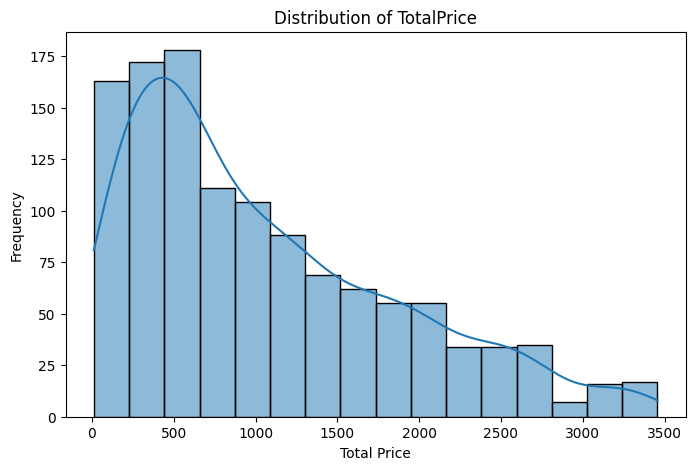

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalPrice"], kde=True)

plt.title("Distribution of TotalPrice")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.show()

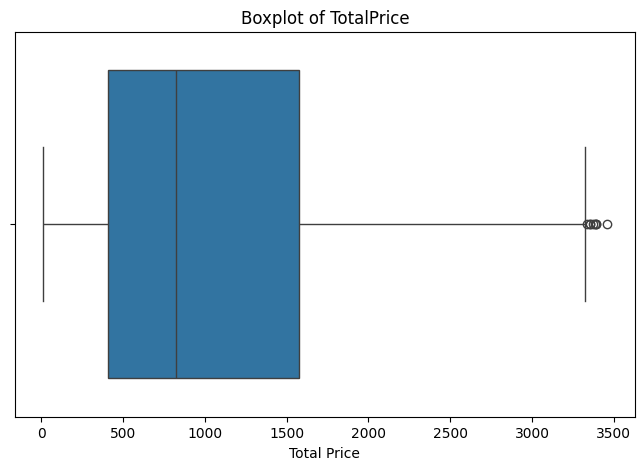

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["TotalPrice"])

plt.title("Boxplot of TotalPrice")
plt.xlabel("Total Price")

plt.show()

In [29]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 410.52
Q3: 1578.475
IQR: 1167.955
Lower Bound: -1341.4125
Upper Bound: 3330.4075


In [30]:
outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 8


In [31]:
outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NaN,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NaN,Facebook,3390.95


In [32]:
df["TotalPrice"].min()

11.39

In [33]:
df["TotalPrice"].max()

3456.4

In [34]:
df.nlargest(10, "TotalPrice")

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NaN,Facebook,3390.95
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NaN,Facebook,3384.90
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1031,ORD201031,2023-02-28,C59183,Phone,5,664.51,136 Main St,Debit Card,Pending,TRK18129706,8,SAVE10,Email,3322.55
463,ORD200463,2023-05-26,C25276,Laptop,5,662.78,214 Main St,Debit Card,Shipped,TRK14011732,9,SAVE10,Instagram,3313.90


In [35]:
df.nsmallest(10, "TotalPrice")

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1161,ORD201161,2023-10-16,C32570,Phone,1,11.39,826 Main St,Cash,Cancelled,TRK35969968,6,WINTER15,Email,11.39
863,ORD200863,2024-05-20,C98276,Phone,1,14.06,471 Main St,Credit Card,Pending,TRK74207282,5,SAVE10,Referral,14.06
240,ORD200240,2023-07-12,C14983,Tablet,1,17.24,255 Main St,Online,Pending,TRK93444157,2,FREESHIP,Instagram,17.24
542,ORD200542,2023-11-14,C49726,Tablet,1,17.98,934 Main St,Cash,Cancelled,TRK20739460,6,FREESHIP,Email,17.98
336,ORD200336,2023-12-29,C88174,Laptop,1,18.20,441 Main St,Debit Card,Pending,TRK10143345,4,SAVE10,Instagram,18.20
776,ORD200776,2023-08-21,C69168,Tablet,1,21.19,482 Main St,Cash,Returned,TRK10446197,5,WINTER15,Google,21.19
1025,ORD201025,2025-05-17,C28406,Chair,1,23.53,174 Main St,Gift Card,Delivered,TRK98841457,2,FREESHIP,Instagram,23.53
690,ORD200690,2024-07-12,C29318,Monitor,1,24.48,128 Main St,Gift Card,Returned,TRK88666721,1,NaN,Instagram,24.48
926,ORD200926,2024-03-20,C67533,Desk,1,26.95,672 Main St,Cash,Delivered,TRK14566395,1,WINTER15,Email,26.95
473,ORD200473,2025-02-25,C28552,Chair,2,14.93,449 Main St,Online,Shipped,TRK71597160,4,NaN,Facebook,29.86


In [36]:
df.columns.tolist()

['OrderID',
 'Date',
 'CustomerID',
 'Product',
 'Quantity',
 'UnitPrice',
 'ShippingAddress',
 'PaymentMethod',
 'OrderStatus',
 'TrackingNumber',
 'ItemsInCart',
 'CouponCode',
 'ReferralSource',
 'TotalPrice']

In [37]:
df["UnitPrice"].value_counts()

,count
UnitPrice,
133.39,2
466.42,2
183.67,2
136.84,2
629.34,2
...,...
427.06,1
287.13,1
127.41,1


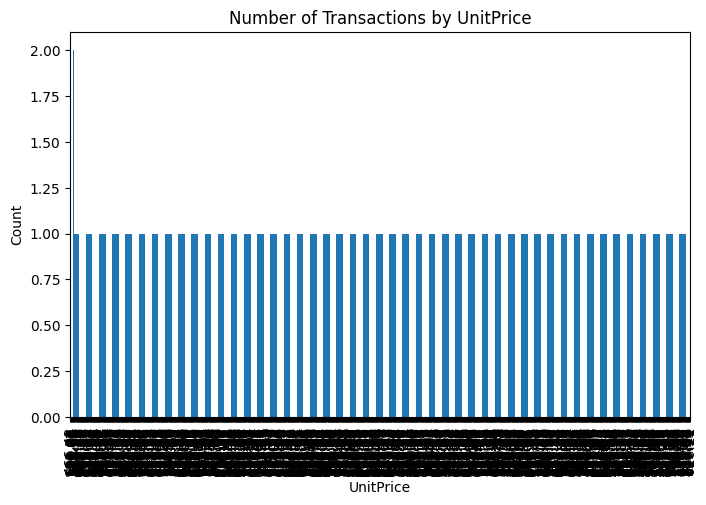

In [40]:
plt.figure(figsize=(8,5))

df["UnitPrice"].value_counts().plot(kind="bar")

plt.title("Number of Transactions by UnitPrice")
plt.xlabel("UnitPrice")
plt.ylabel("Count")

plt.show()

In [41]:
df.groupby("UnitPrice")["TotalPrice"].mean()

,TotalPrice
UnitPrice,
11.39,11.39
12.10,48.40
14.06,14.06
14.69,58.76
14.93,29.86
...,...
697.19,1394.38
697.50,2790.00
697.93,1395.86


In [42]:
df.groupby("UnitPrice")["TotalPrice"].sum()

,TotalPrice
UnitPrice,
11.39,11.39
12.10,48.40
14.06,14.06
14.69,58.76
14.93,29.86
...,...
697.19,1394.38
697.50,2790.00
697.93,1395.86


In [43]:
df.select_dtypes(include=np.number).columns

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], dtype='object')

In [44]:
correlation = df.select_dtypes(include=np.number).corr()

correlation

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


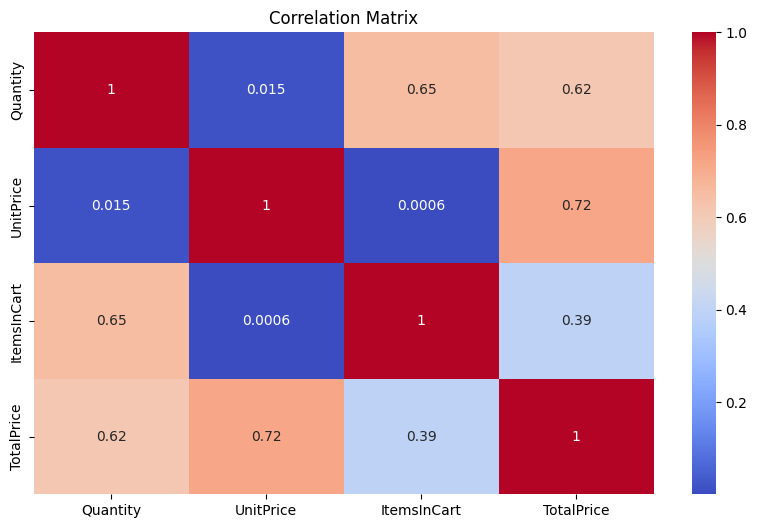

In [45]:
plt.figure(figsize=(10,6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [46]:
print("Total number of records:", df["TotalPrice"].count())
print("Average TotalPrice:", df["TotalPrice"].mean())
print("Median TotalPrice:", df["TotalPrice"].median())
print("Minimum TotalPrice:", df["TotalPrice"].min())
print("Maximum TotalPrice:", df["TotalPrice"].max())
print("Number of potential outliers:", len(outliers))

Total number of records: 1200
Average TotalPrice: 1053.9683
Median TotalPrice: 823.615
Minimum TotalPrice: 11.39
Maximum TotalPrice: 3456.4
Number of potential outliers: 8


## Conclusion

The exploratory data analysis was performed on the sales dataset using the TotalPrice variable. Basic statistical measures including count, mean, and median were calculated to understand the data. The distribution and boxplot were used to examine the pattern of TotalPrice and identify potential outliers. The analysis provides a clear understanding of the transaction price data and helps identify unusual values and overall patterns in the dataset.